In [1]:
import numpy as np
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
mat_df = pd.read_csv(r"student-mat.csv")
por_df = pd.read_csv(r"student-por.csv")

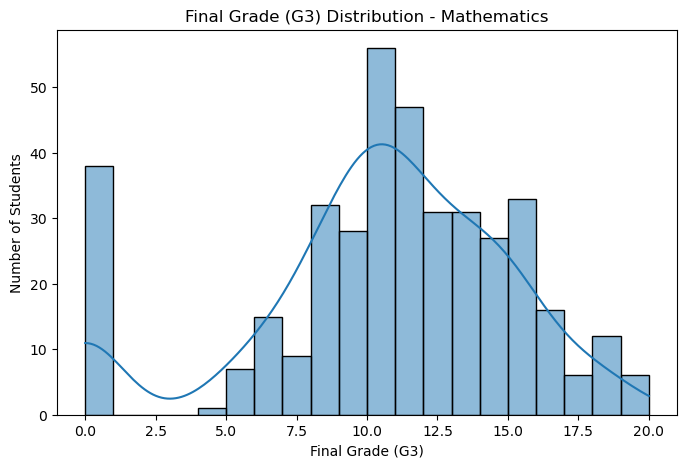

In [3]:
plt.figure(figsize=(8, 5))

sns.histplot(data=mat_df, x='G3', bins=20, kde=True)

plt.title("Final Grade (G3) Distribution - Mathematics")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.show()
# Observation:
# Mathematics final grades are mainly concentrated between 8 and 16, with the highest frequency around 10–12.
# A noticeable number of students have a final grade of 0, while very few students score above 18.

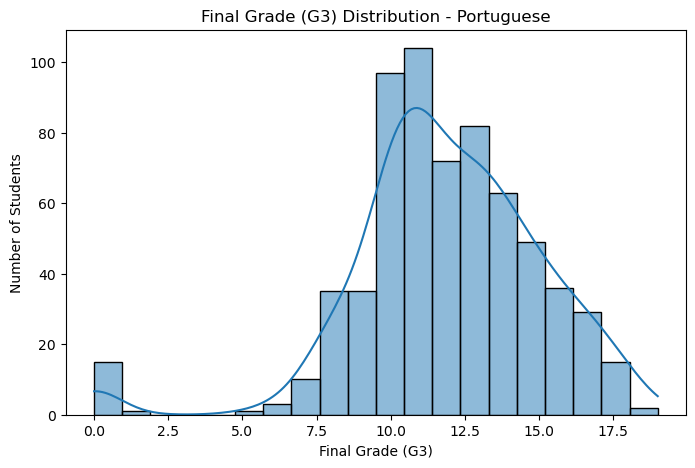

In [4]:
plt.figure(figsize=(8, 5))

sns.histplot(data=por_df, x='G3', bins=20, kde=True)

plt.title("Final Grade (G3) Distribution - Portuguese")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.show()
# Observation:
# Portuguese final grades are mainly concentrated between 9 and 16, with the highest frequency around 11–13.
# Most students achieve moderate grades, while a smaller number have very low or very high scores.

In [5]:
# 2. Add a 'subject' column to distinguish them, then combine
mat_df['subject'] = 'Math'
por_df['subject'] = 'Portuguese'
df = pd.concat([mat_df, por_df], ignore_index=True)

In [6]:
df.to_csv('combined_student_data.csv', index=False)

In [7]:
# 3. Feature Engineering: Combine Mother and Father education levels
df['Parent_Edu'] = df['Medu'] + df['Fedu']
# 4. Set a consistent, professional visual theme for all plots
sns.set_theme(style="whitegrid", palette="Set2")

In [8]:
print(f"Data combined successfully! Total student records: {len(df)}")

Data combined successfully! Total student records: 1044


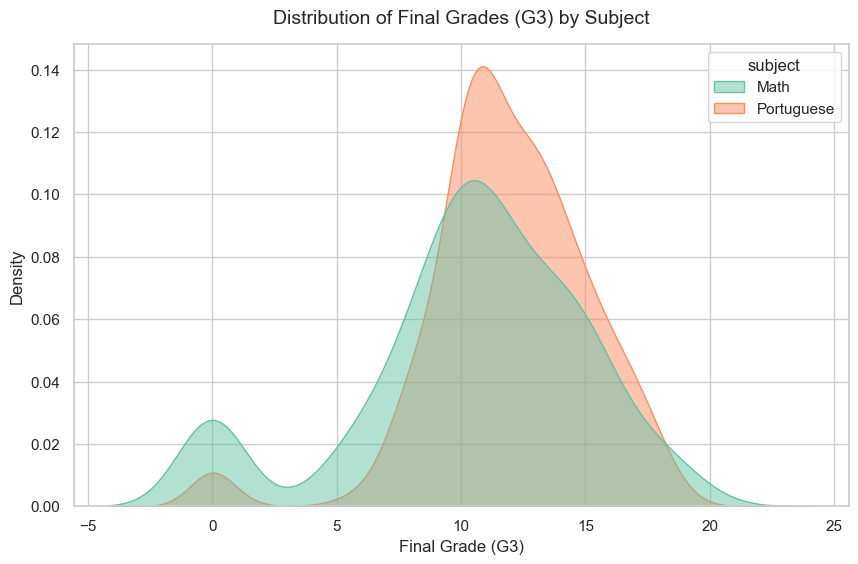

In [9]:
# Graph 1: Distribution of Final Grades (G3) by Subject
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='G3', hue='subject', fill=True, common_norm=False, alpha=0.5)
plt.title('Distribution of Final Grades (G3) by Subject', fontsize=14, pad=15)
plt.xlabel('Final Grade (G3)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.savefig('Graph_1_Workday_Alcohol.png', dpi=300)
plt.show()

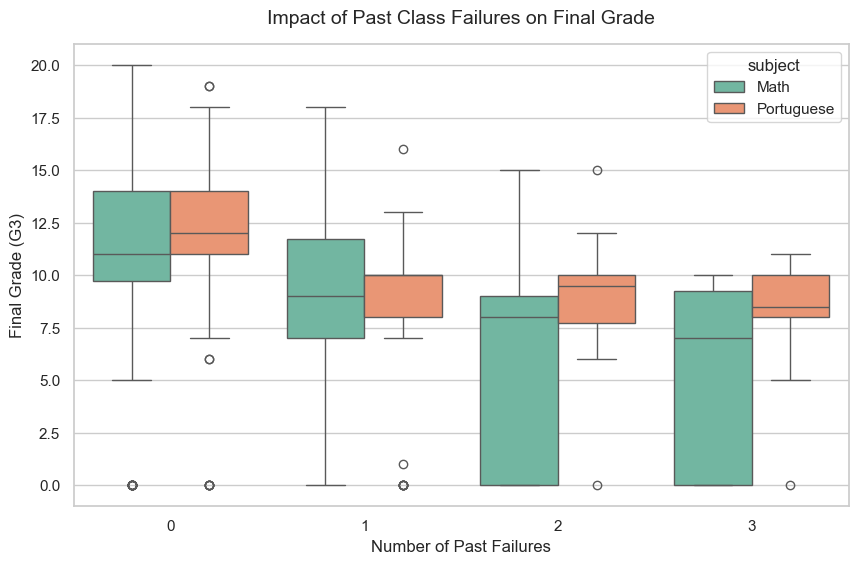

In [10]:
# Graph 2: Impact of Past Class Failures on Final Grade
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='failures', y='G3', hue='subject')
plt.title('Impact of Past Class Failures on Final Grade', fontsize=14, pad=15)
plt.xlabel('Number of Past Failures', fontsize=12)
plt.ylabel('Final Grade (G3)', fontsize=12)
plt.savefig('Graph_2_Failures_vs_Grades.png', dpi=300, bbox_inches='tight')
plt.show()

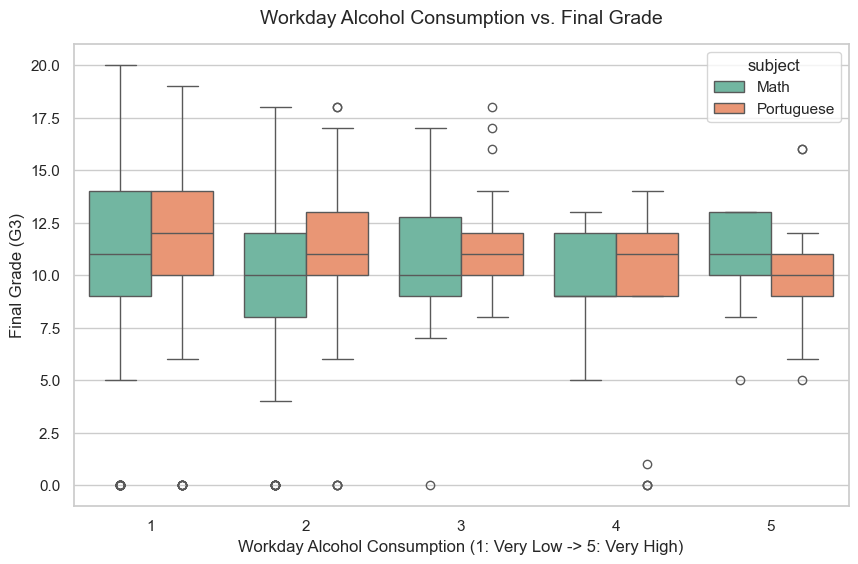

In [11]:
# Graph 3: Workday Alcohol Consumption vs. Final Grade
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Dalc', y='G3', hue='subject')
plt.title('Workday Alcohol Consumption vs. Final Grade', fontsize=14, pad=15)
plt.xlabel('Workday Alcohol Consumption (1: Very Low -> 5: Very High)', fontsize=12)
plt.ylabel('Final Grade (G3)', fontsize=12)
plt.savefig('Graph_2_Failures_vs_Grades.png', dpi=300, bbox_inches='tight')
plt.show()

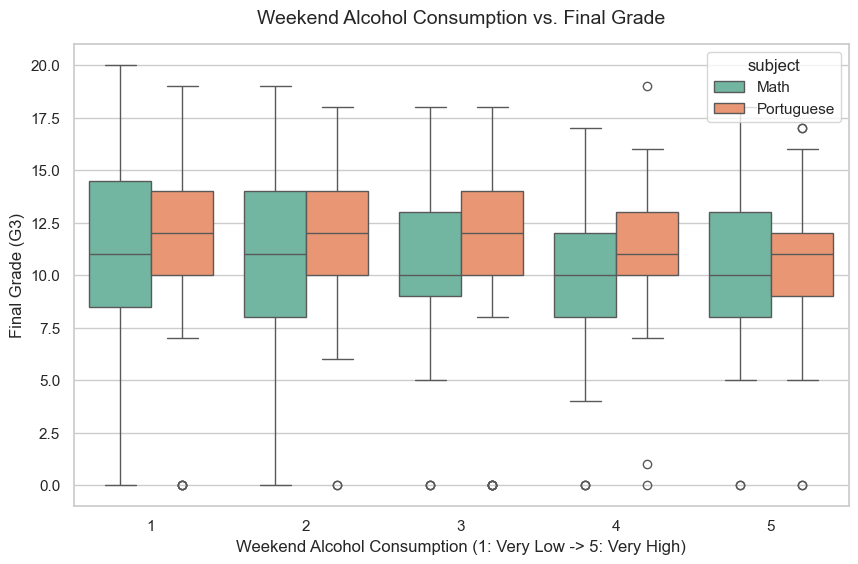

In [12]:
# Graph 4: Weekend Alcohol Consumption vs. Final Grade
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Walc', y='G3', hue='subject')
plt.title('Weekend Alcohol Consumption vs. Final Grade', fontsize=14, pad=15)
plt.xlabel('Weekend Alcohol Consumption (1: Very Low -> 5: Very High)', fontsize=12)
plt.ylabel('Final Grade (G3)', fontsize=12)
plt.savefig('Graph_4_Weekend_Alcohol.png', dpi=300, bbox_inches='tight')
plt.show()

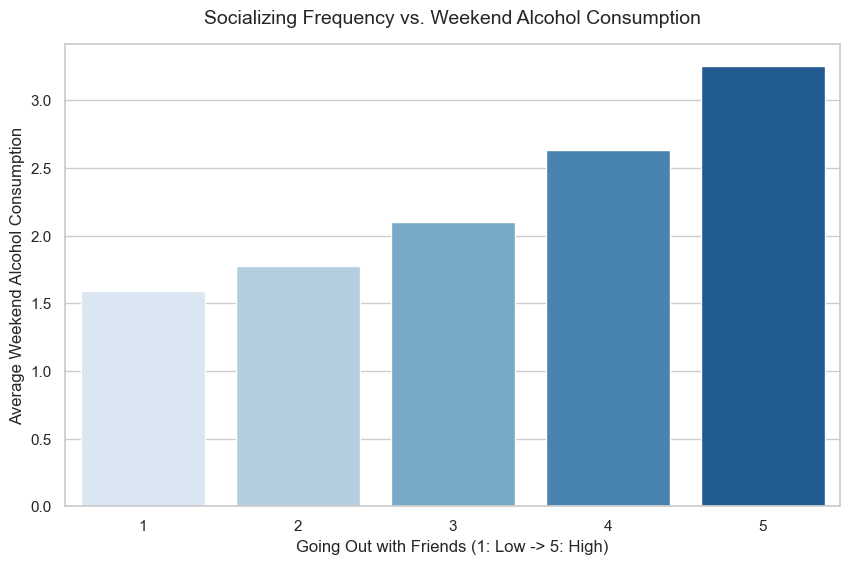

In [13]:
# Graph 5: Socializing Frequency vs. Weekend Alcohol Consumption
fig5, ax5 = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, x='goout', y='Walc', errorbar=None, palette='Blues', ax=ax5)
ax5.set_title('Socializing Frequency vs. Weekend Alcohol Consumption', fontsize=14, pad=15)
ax5.set_xlabel('Going Out with Friends (1: Low -> 5: High)', fontsize=12)
ax5.set_ylabel('Average Weekend Alcohol Consumption', fontsize=12)
plt.savefig('Graph_5_Socializing_vs_Alcohol.png', dpi=300, bbox_inches='tight')
plt.show()

Text(0, 0.5, 'Average School Absences')

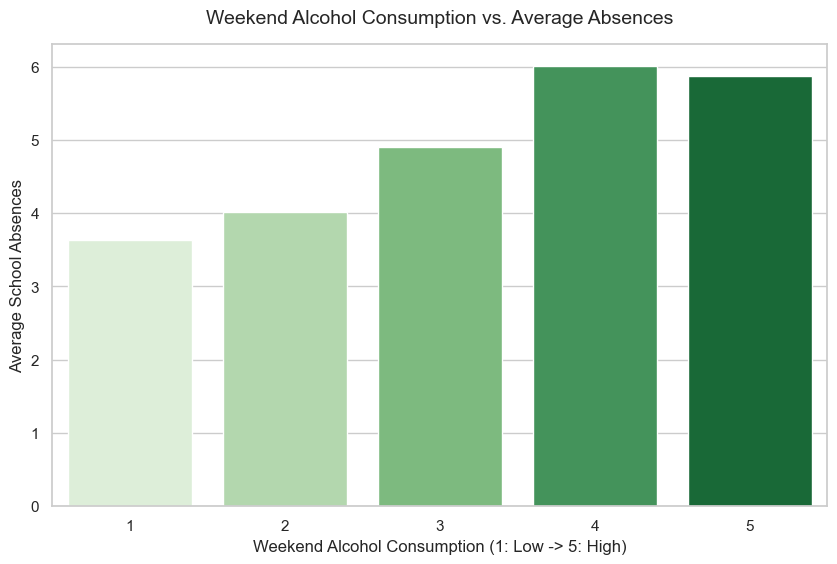

In [14]:
fig6, ax6 = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, x='Walc', y='absences', errorbar=None, palette='Greens', ax=ax6)
ax6.set_title('Weekend Alcohol Consumption vs. Average Absences', fontsize=14, pad=15)
ax6.set_xlabel('Weekend Alcohol Consumption (1: Low -> 5: High)', fontsize=12)
ax6.set_ylabel('Average School Absences', fontsize=12)

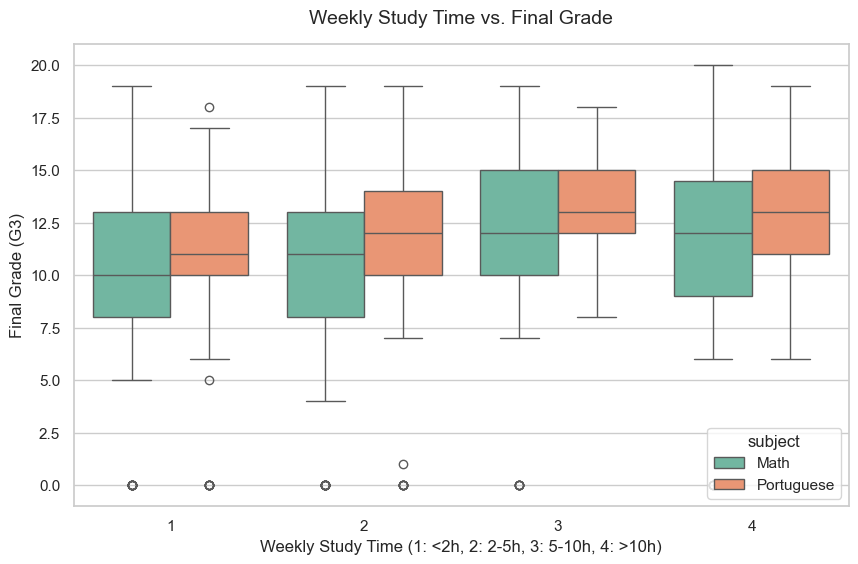

In [15]:
# Graph 7: Weekly Study Time vs. Final Grade
fig7, ax7 = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='studytime', y='G3', hue='subject', ax=ax7)
ax7.set_title('Weekly Study Time vs. Final Grade', fontsize=14, pad=15)
ax7.set_xlabel('Weekly Study Time (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)', fontsize=12)
ax7.set_ylabel('Final Grade (G3)', fontsize=12)
plt.savefig('Graph_7_StudyTime_vs_Grades.png', dpi=300, bbox_inches='tight')
plt.show()

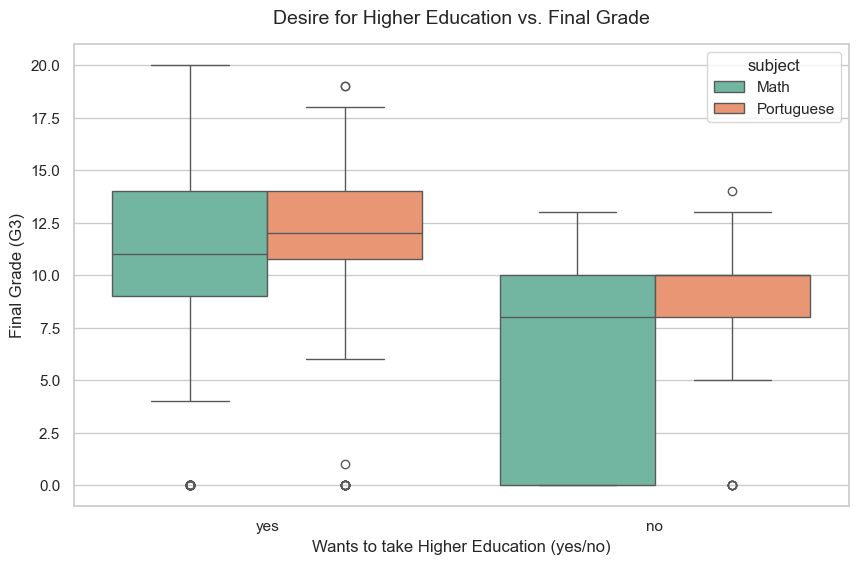

In [16]:
        # Graph 8: Desire for Higher Education vs. Final Grade
fig8, ax8 = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='higher', y='G3', hue='subject', ax=ax8)
ax8.set_title('Desire for Higher Education vs. Final Grade', fontsize=14, pad=15)
ax8.set_xlabel('Wants to take Higher Education (yes/no)', fontsize=12)
ax8.set_ylabel('Final Grade (G3)', fontsize=12)
plt.savefig('Graph_8_StudyTime_vs_Grades.png', dpi=300, bbox_inches='tight')
plt.show()

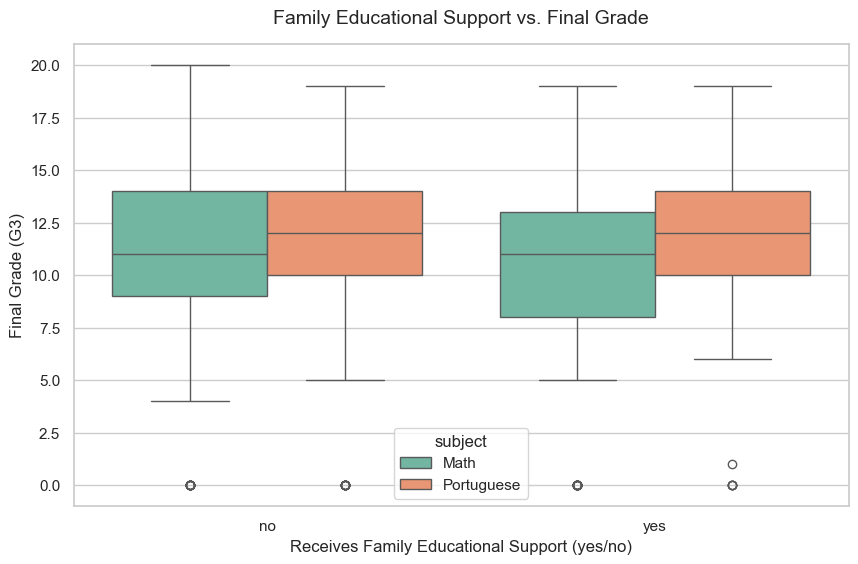

In [17]:
# Graph 9: Family Educational Support vs. Final Grade
fig9, ax9 = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='famsup', y='G3', hue='subject', ax=ax9)
ax9.set_title('Family Educational Support vs. Final Grade', fontsize=14, pad=15)
ax9.set_xlabel('Receives Family Educational Support (yes/no)', fontsize=12)
ax9.set_ylabel('Final Grade (G3)', fontsize=12)

plt.savefig('Graph_9_FamSup_vs_Grades.png', dpi=300, bbox_inches='tight')
plt.show()

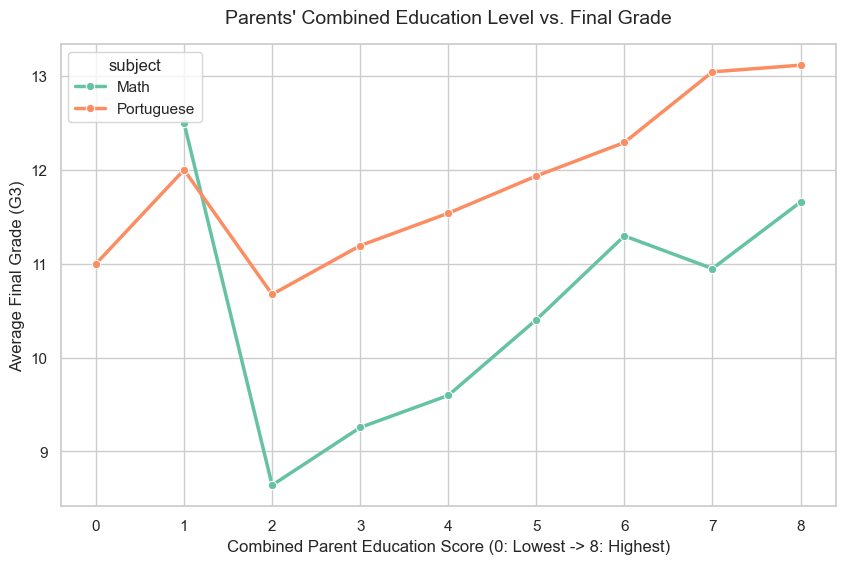

In [18]:
# Graph 10: Parents' Combined Education Level vs. Final Grade
fig10, ax10 = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df, x='Parent_Edu', y='G3', hue='subject', marker='o', errorbar=None, linewidth=2.5, ax=ax10)
ax10.set_title("Parents' Combined Education Level vs. Final Grade", fontsize=14, pad=15)
ax10.set_xlabel("Combined Parent Education Score (0: Lowest -> 8: Highest)", fontsize=12)
ax10.set_ylabel('Average Final Grade (G3)', fontsize=12)

plt.savefig('Graph_10_ParentEdu_vs_Grades.png', dpi=300, bbox_inches='tight')
plt.show()

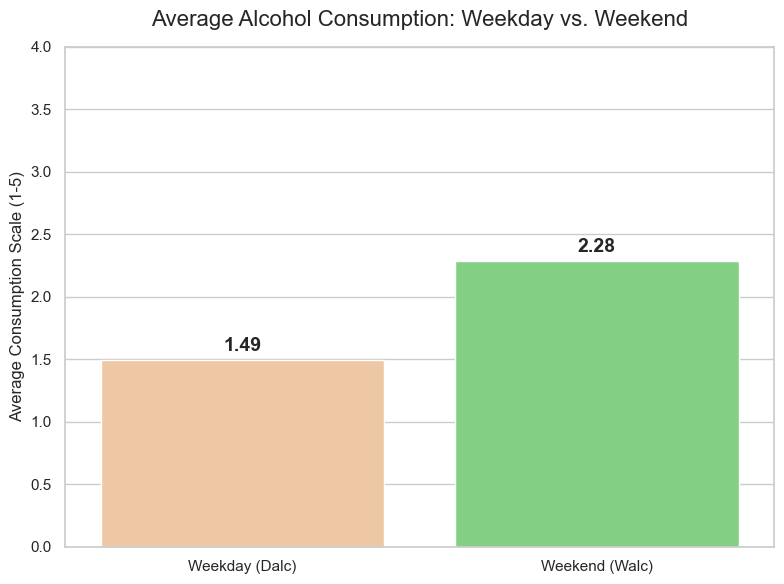

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your dataset
df = pd.read_csv('combined_student_data.csv')

# 2. Calculate the exact averages
dalc_avg = df['Dalc'].mean()
walc_avg = df['Walc'].mean()

# 3. Set the visual style to match your previous graphs
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# 4. Create the bar chart
bars = sns.barplot(
    x=['Weekday (Dalc)', 'Weekend (Walc)'], 
    y=[dalc_avg, walc_avg], 
    palette=['#FAC898', '#76DD78']  # A clean blue and yellow/orange combo
)

# 5. Add titles and axis labels
plt.title('Average Alcohol Consumption: Weekday vs. Weekend', fontsize=16, pad=15)
plt.ylabel('Average Consumption Scale (1-5)', fontsize=12)

# Set the Y-axis limit to 4 to make the bars look well-proportioned
plt.ylim(0, 4) 

# 6. Add the exact numbers on top of the bars!
for p in bars.patches:
    bars.annotate(f"{p.get_height():.2f}", 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='center', 
                  xytext=(0, 10), 
                  textcoords='offset points',
                  fontsize=14, fontweight='bold')

# 7. Save and display
plt.tight_layout()
plt.savefig('Graph_9_Alcohol_Profile.png', dpi=300, bbox_inches='tight')
plt.show()


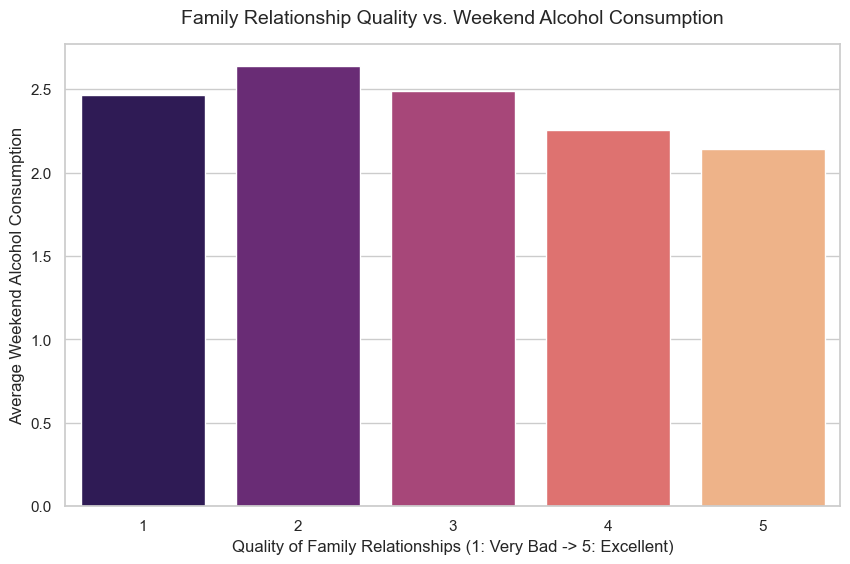

In [19]:
# Graph 11: Family Relationship Quality vs. Weekend Alcohol Consumption
fig11, ax11 = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, x='famrel', y='Walc', palette='magma', errorbar=None, ax=ax11)
ax11.set_title('Family Relationship Quality vs. Weekend Alcohol Consumption', fontsize=14, pad=15)
ax11.set_xlabel('Quality of Family Relationships (1: Very Bad -> 5: Excellent)', fontsize=12)
ax11.set_ylabel('Average Weekend Alcohol Consumption', fontsize=12)

plt.savefig('Graph_11_FamRel_vs_Alcohol.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

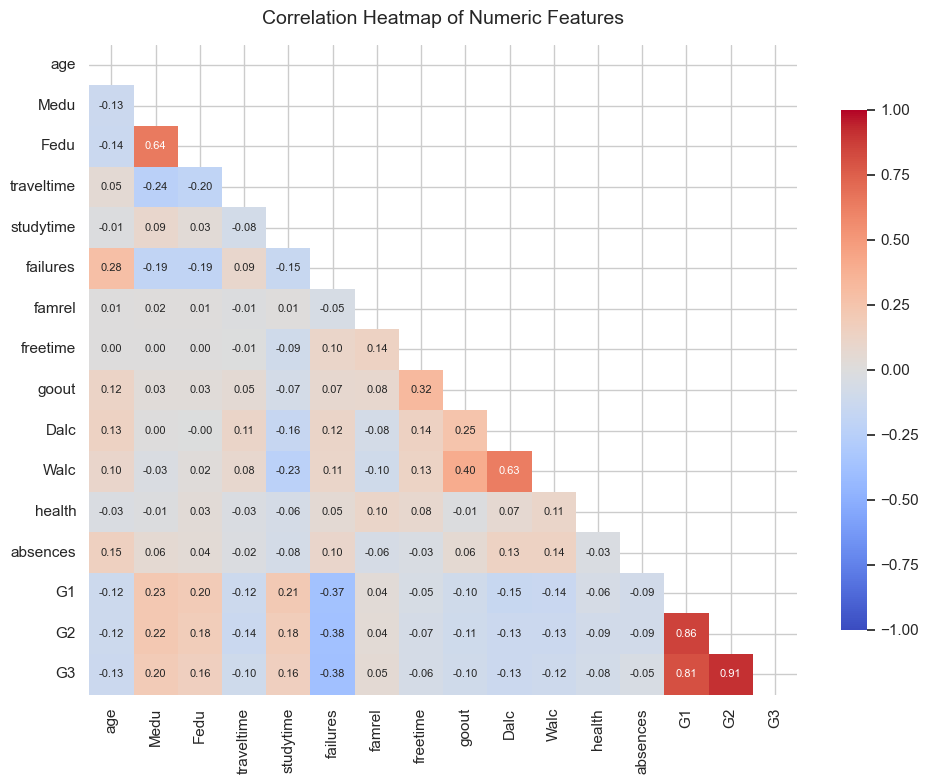

In [20]:
# Graph 12: Correlation Heatmap of Numeric Features
fig12, ax12 = plt.subplots(figsize=(10, 8))
# Select numeric columns for correlation
numeric_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures','famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health','absences', 'G1', 'G2', 'G3']
corr = df[numeric_cols].corr()
# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
# Plot the heatmap with adjusted font sizes for text annotations
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True, fmt=".2f", 
            vmin=-1, vmax=1, ax=ax12, cbar_kws={"shrink": .8}, 
            annot_kws={"size": 8})
ax12.set_title('Correlation Heatmap of Numeric Features', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('Graph_12_Correlation_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()